In [75]:
import torch

x = torch.tensor(5.0)  # input tensor
y = torch.tensor([15.3])  # target tensor
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
z = x*w+b
z.detach()

tensor([-0.2780])

In [76]:
optimizer = torch.optim.SGD([w, b], lr=0.0001)

In [ ]:
for i in range(10000):
    x = torch.randn(1)
    y = x.detach() * 3.0 + 1 + torch.randn(1) * 10
    y_hat = x*w+b
    loss = torch.nn.functional.mse_loss(y_hat, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    if i % 10 == 0:
        print(loss.item())

43.85806655883789
135.78573608398438
80.27812957763672
171.47059631347656
14.672388076782227
103.16795349121094
364.3185119628906
37.328372955322266
8.124165534973145
37.80929946899414
30.264856338500977
143.6212158203125
0.041331905871629715
0.011227398179471493
332.0587463378906
148.6470184326172
119.22626495361328
15.265763282775879
82.36006927490234
47.66838073730469
7.612824440002441
244.0859375
0.9032127857208252
134.2363739013672
17.348865509033203
53.607948303222656
283.7480163574219
184.73699951171875
84.176513671875
89.7509994506836
65.33760833740234
467.6754455566406
308.77197265625
56.265380859375
134.48684692382812
34.59355926513672
0.43267881870269775
6.696606636047363
145.537353515625
16.740772247314453
155.62374877929688
16.015094757080078
0.18859003484249115
304.0624084472656
31.33107566833496
260.60357666015625
6.610213279724121
314.0709228515625
22.78664779663086
1.3526597023010254
0.2092532217502594
2.0900707244873047
106.82627868652344
62.19313430786133
25.21963500

In [78]:
print(f"Trained parameters: w={w.item():.4f}, b={b.item():.4f}")

Trained parameters: w=2.5704, b=1.1157


# ADR

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

import pvlib
from pvlib import iotools, location

PVLIB_DIR = pvlib.__path__[0]
DATA_FILE = os.path.join(PVLIB_DIR, 'data', '723170TYA.CSV')

tmy, metadata = iotools.read_tmy3(DATA_FILE, coerce_year=1990,
                                  map_variables=True)

df = pd.DataFrame({'ghi': tmy['ghi'], 'dhi': tmy['dhi'], 'dni': tmy['dni'],
                   'temp_air': tmy['temp_air'],
                   'wind_speed': tmy['wind_speed']})

In [2]:
df.index = df.index - pd.Timedelta(minutes=30)

loc = location.Location.from_tmy(metadata)
solpos = loc.get_solarposition(df.index)

In [10]:
import torch

unix_timestamps = [1654041600, 1654042500, 1654043400, 1654044300, 1654045200, 1654046100,
        1654047000, 1654047900, 1654048800, 1654049700, 1654050600, 1654051500,
        1654052400, 1654053300, 1654054200, 1654055100, 1654056000, 1654056900,
        1654057800, 1654058700, 1654059600, 1654060500, 1654061400, 1654062300,
        1654063200, 1654064100, 1654065000, 1654065900, 1654066800, 1654067700,
        1654068600, 1654069500, 1654070400, 1654071300, 1654072200, 1654073100,
        1654074000, 1654074900, 1654075800, 1654076700, 1654077600, 1654078500,
        1654079400, 1654080300, 1654081200, 1654082100, 1654083000, 1654083900,
        1654084800, 1654085700, 1654086600, 1654087500, 1654088400, 1654089300,
        1654090200, 1654091100, 1654092000, 1654092900, 1654093800, 1654094700,
        1654095600, 1654096500, 1654097400, 1654098300, 1654099200, 1654100100,
        1654101000, 1654101900, 1654102800, 1654103700, 1654104600, 1654105500,
        1654106400, 1654107300, 1654108200, 1654109100, 1654110000, 1654110900,
        1654111800, 1654112700, 1654113600, 1654114500, 1654115400, 1654116300,
        1654117200, 1654118100, 1654119000, 1654119900, 1654120800, 1654121700,
        1654122600, 1654123500, 1654124400, 1654125300, 1654126200, 1654127100]
solpos = loc.get_solarposition(pd.to_datetime(torch.tensor(unix_timestamps), unit="s"))

In [119]:
solar_zenith = torch.deg2rad(torch.tensor(solpos.apparent_zenith.values))
solar_azimuth = torch.deg2rad(torch.tensor(solpos.azimuth.values))

In [164]:
TILT = torch.deg2rad(torch.tensor(metadata['latitude']))
ORIENT = torch.deg2rad(torch.tensor(180))

dhi = torch.tensor(df['dhi'].values)
ghi = torch.tensor(df['ghi'].values)
dni = torch.tensor(df['dni'].values)
wind_speed = torch.tensor(df['wind_speed'].values)
temp_air = torch.tensor(df['temp_air'].values)

# param
albedo = torch.tensor(0.25, requires_grad=True)

sky_diffuse = dhi * (1 + torch.cos(TILT)) * 0.5
ground_diffuse = ghi * albedo * (1 - torch.cos(TILT)) * 0.5

In [155]:
projection = (
    torch.cos(TILT) * torch.cos(solar_zenith) +
    torch.sin(TILT) * torch.sin(solar_zenith) *
    torch.cos(solar_azimuth - ORIENT))

projection = torch.clip(projection, -1, 1)

aoi = torch.acos(projection)

In [157]:
poa_direct = torch.maximum(dni * torch.cos(aoi), torch.tensor(0.0))
poa_diffuse = sky_diffuse + ground_diffuse
poa_global = poa_direct + poa_diffuse

In [160]:
# params
u0 = torch.tensor(25.0, requires_grad=True)
u1 = torch.tensor(7.0, requires_grad=True)

total_loss_factor = u0 + u1 * wind_speed
heat_input = poa_global
temp_difference = heat_input / total_loss_factor
pv_temp = temp_air + temp_difference

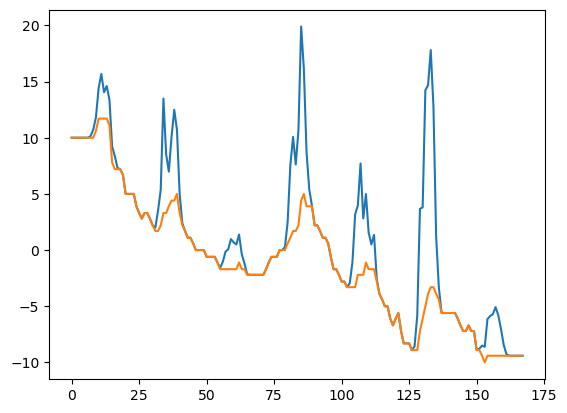

In [165]:
plt.plot(pv_temp.detach().numpy()[0:24*7], label='Predicted PV Temp')
plt.plot(temp_air.numpy()[0:24*7], label='Air Temp')

In [166]:
# Borrow the ADR model parameters from the other example:

adr_params = {'k_a': 0.99924,
              'k_d': -5.49097,
              'tc_d': 0.01918,
              'k_rs': 0.06999,
              'k_rsh': 0.26144
              }

k_a = torch.tensor(adr_params['k_a'], requires_grad=True)
k_d = torch.tensor(adr_params['k_d'], requires_grad=True)
tc_d = torch.tensor(adr_params['tc_d'], requires_grad=True)
k_rs = torch.tensor(adr_params['k_rs'], requires_grad=True)
k_rsh = torch.tensor(adr_params['k_rsh'], requires_grad=True)

# normalize the irradiance
G_REF = torch.tensor(1000.)
s = poa_global / G_REF

# obtain the difference from reference temperature
T_REF = torch.tensor(25.)
dt = pv_temp - T_REF

s_o     = 10**(k_d + (dt * tc_d))
s_o_ref = 10**(k_d)

v  = torch.log(s / s_o     + 1)
v /= torch.log(1 / s_o_ref + 1)

eta = k_a * ((1 + k_rs + k_rsh) * v - k_rs * s - k_rsh * v**2)

# Set the desired array size:
P_STC = 5000.   # (W)

# and the irradiance level needed to achieve this output:
G_STC = 1000.   # (W/m2)

pv_output = P_STC * eta * (poa_global / G_STC)

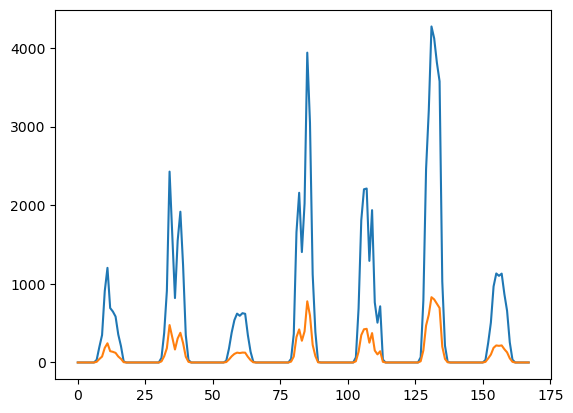

In [172]:
plt.plot(pv_output.detach().numpy()[0:24*7])
plt.plot(poa_global.detach().numpy()[0:24*7])

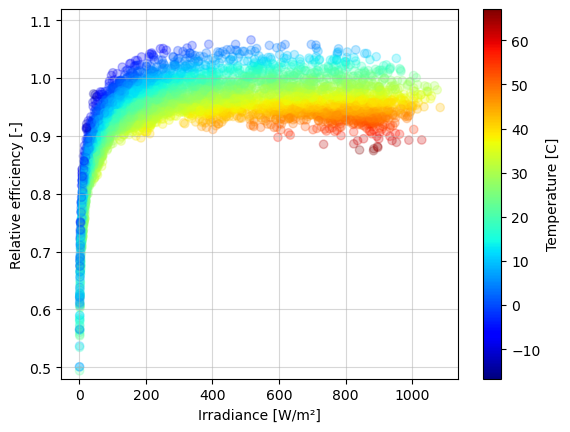

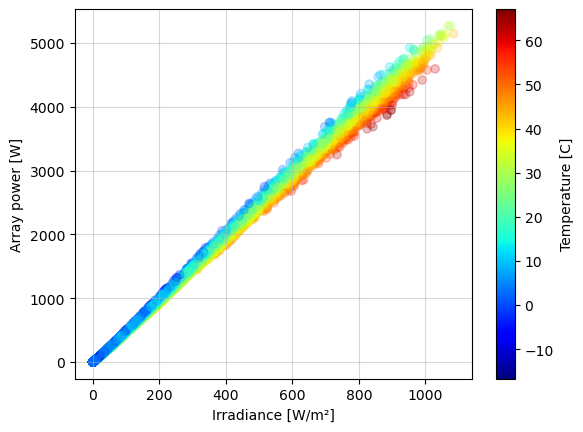

In [175]:
plt.figure()
pc = plt.scatter(poa_global.detach().numpy(), eta.detach().numpy(), c=pv_temp.detach().numpy(), cmap='jet')
plt.colorbar(label='Temperature [C]', ax=plt.gca())
pc.set_alpha(0.25)
plt.grid(alpha=0.5)
plt.ylim(0.48)
plt.xlabel('Irradiance [W/m²]')
plt.ylabel('Relative efficiency [-]')
plt.show()

plt.figure()
pc = plt.scatter(poa_global.detach().numpy(), pv_output.detach().numpy(), c=pv_temp.detach().numpy(), cmap='jet')
plt.colorbar(label='Temperature [C]', ax=plt.gca())
pc.set_alpha(0.25)
plt.grid(alpha=0.5)
plt.xlabel('Irradiance [W/m²]')
plt.ylabel('Array power [W]')
plt.show()

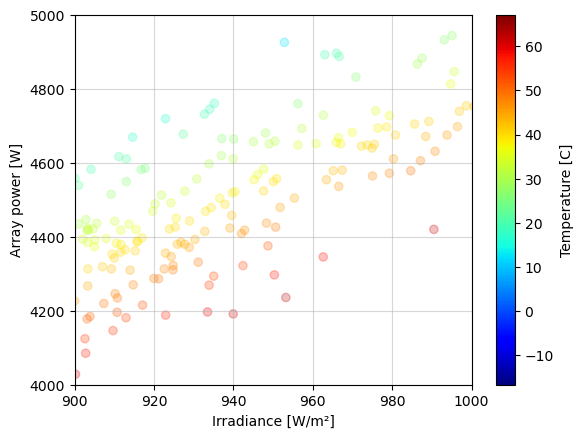

In [178]:
plt.figure()
pc = plt.scatter(poa_global.detach().numpy(), pv_output.detach().numpy(), c=pv_temp.detach().numpy(), cmap='jet')
plt.colorbar(label='Temperature [C]', ax=plt.gca())
pc.set_alpha(0.25)
plt.grid(alpha=0.5)
plt.xlabel('Irradiance [W/m²]')
plt.ylabel('Array power [W]')
plt.xlim(900, 1000)
plt.ylim(4000, 5000)
plt.show()